In [ ]:
import torch
import torch.nn as nn

import torchvision.models as models
import torchvision.transforms as transforms

import requests
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

In [ ]:
# ============================================================
# LOAD PRETRAINED MODEL
# ============================================================

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

model.eval()

print("Model Loaded Successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Model Loaded Successfully


In [ ]:
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

labels = requests.get(
    LABELS_URL
).text.split("\n")

print("Classes:", len(labels))
print(labels)

Classes: 1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', '

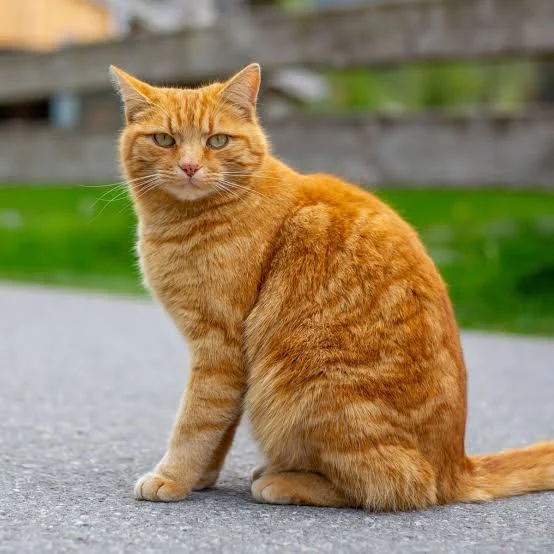

In [ ]:
# Using the static filename from the previous upload
filename = 'images (1).webp'

image = Image.open(
    filename
).convert("RGB")

image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

input_tensor = transform(
    image
).unsqueeze(0)

In [ ]:
def predict(model, image, labels):

    with torch.no_grad():

        output = model(image)

        probs = torch.softmax(
            output,
            dim=1
        )

        idx = probs.argmax(
            dim=1
        ).item()

    return {
        "index": idx,
        "label": labels[idx],
        "confidence": probs[0][idx].item()
    }

In [ ]:
def fgsm_(model,
          x,
          target,
          eps,
          targeted=True,
          clip_min=None,
          clip_max=None):

    x_adv = x.clone().detach()

    x_adv.requires_grad_(True)

    logits = model(x_adv)

    target = torch.LongTensor([target])

    loss = nn.CrossEntropyLoss()(
        logits,
        target
    )

    model.zero_grad()

    loss.backward()

    grad = x_adv.grad.data

    if targeted:

        x_adv = (
            x_adv -
            eps * grad.sign()
        )

    else:

        x_adv = (
            x_adv +
            eps * grad.sign()
        )

    if clip_min is not None or clip_max is not None:

        x_adv.clamp_(
            min=clip_min,
            max=clip_max
        )

    return x_adv

In [ ]:
def fgsm_targeted(
        model,
        x,
        target,
        eps,
        **kwargs):

    return fgsm_(
        model,
        x,
        target,
        eps,
        targeted=True,
        **kwargs
    )


def fgsm_untargeted(
        model,
        x,
        label,
        eps,
        **kwargs):

    return fgsm_(
        model,
        x,
        label,
        eps,
        targeted=False,
        **kwargs
    )

In [ ]:
def pgd_(model,
         x,
         target,
         k,
         eps,
         eps_step,
         targeted=True,
         clip_min=None,
         clip_max=None):

    x_min = x - eps
    x_max = x + eps

    x_adv = x.clone()

    x_adv += eps * (
        2 * torch.rand_like(x_adv) - 1
    )

    for _ in range(k):

        x_adv = fgsm_(
            model,
            x_adv,
            target,
            eps_step,
            targeted=targeted
        )

        x_adv = torch.max(
            x_min,
            x_adv
        )

        x_adv = torch.min(
            x_max,
            x_adv
        )

    if clip_min is not None or clip_max is not None:

        x_adv.clamp_(
            min=clip_min,
            max=clip_max
        )

    return x_adv

In [ ]:
def pgd_targeted(
        model,
        x,
        target,
        k,
        eps,
        eps_step,
        **kwargs):

    return pgd_(
        model,
        x,
        target,
        k,
        eps,
        eps_step,
        targeted=True,
        **kwargs
    )


def pgd_untargeted(
        model,
        x,
        label,
        k,
        eps,
        eps_step,
        **kwargs):

    return pgd_(
        model,
        x,
        label,
        k,
        eps,
        eps_step,
        targeted=False,
        **kwargs
    )

In [ ]:
mean = np.array(
    [0.485,0.456,0.406]
)

std = np.array(
    [0.229,0.224,0.225]
)

def tensor_to_image(tensor):

    img = tensor.squeeze().detach().numpy()

    img = np.transpose(
        img,
        (1,2,0)
    )

    img = std * img + mean

    img = np.clip(
        img,
        0,
        1
    )

    return img

In [ ]:
def show(original,
         adv,
         labels,
         model):

    orig_pred = predict(
        model,
        original,
        labels
    )

    adv_pred = predict(
        model,
        adv,
        labels
    )

    noise = (
        adv -
        original
    )

    noise = noise.squeeze().detach().numpy()

    noise = np.transpose(
        noise,
        (1,2,0)
    )

    noise = (
        noise -
        noise.min()
    ) / (
        noise.max() -
        noise.min()
    )

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(
        tensor_to_image(original)
    )
    plt.title(
        f"{orig_pred['label']}\n"
        f"{orig_pred['confidence']*100:.2f}%"
    )
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(noise)
    plt.title("Perturbation")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(
        tensor_to_image(adv)
    )
    plt.title(
        f"{adv_pred['label']}\n"
        f"{adv_pred['confidence']*100:.2f}%"
    )
    plt.axis("off")

    plt.show()

In [ ]:
result = predict(
    model,
    input_tensor,
    labels
)

print(result)

{'index': 282, 'label': 'tiger cat', 'confidence': 0.8790810704231262}


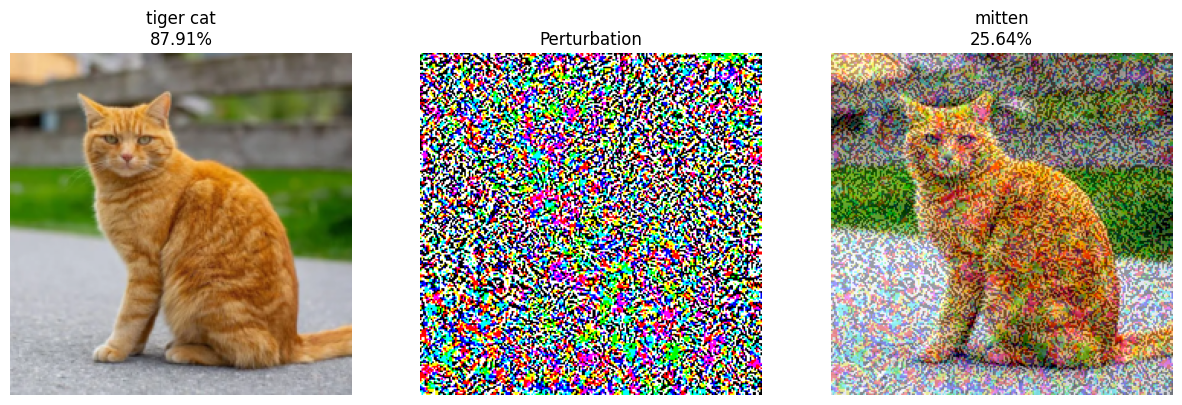

In [ ]:
# Targeted class index (999: toilet tissue)
target_idx = 88

adv = fgsm_targeted(
    model,
    input_tensor,
    target=target_idx,
    eps=0.8
)

show(
    input_tensor,
    adv,
    labels,
    model
)

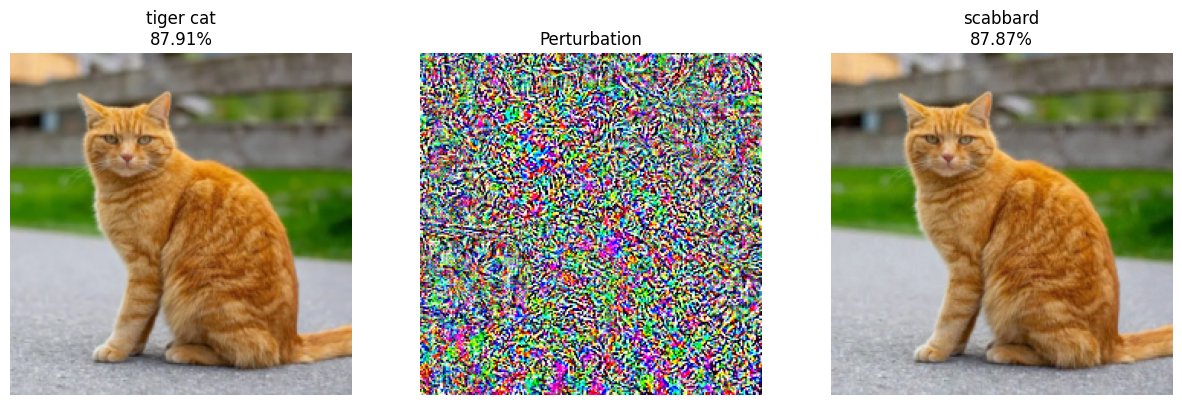

In [ ]:
# Targeted class index (999: toilet tissue)
target_idx = 777

adv = pgd_targeted(
    model,
    input_tensor,
    target=target_idx,
    k=10,
    eps=0.03,
    eps_step=0.005
)

show(
    input_tensor,
    adv,
    labels,
    model
)